## Decision Tree
A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by splitting the dataset into subsets based on feature values, creating a tree-like structure of decisions.

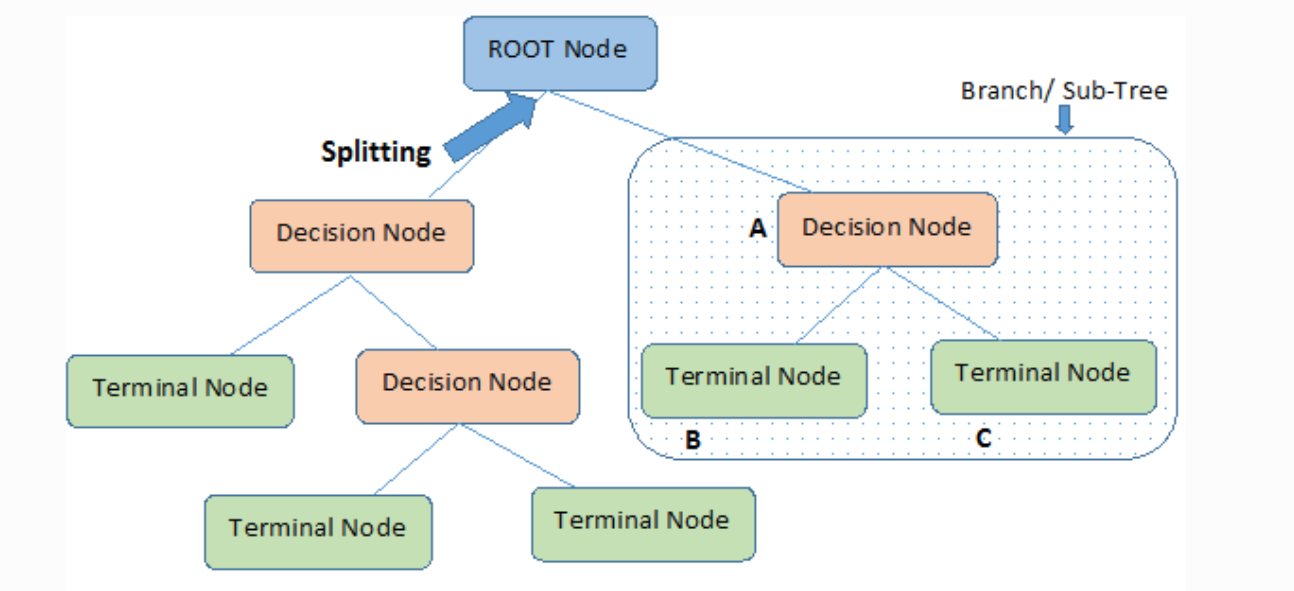

## Decision Tree Classifier
Used when the target variable is categorical (e.g., yes/no, red/blue/green)<==>Output: Class labels.
## How Decision Trees Work 

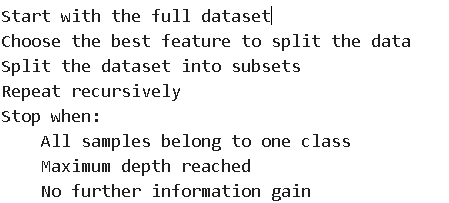
## Entropy
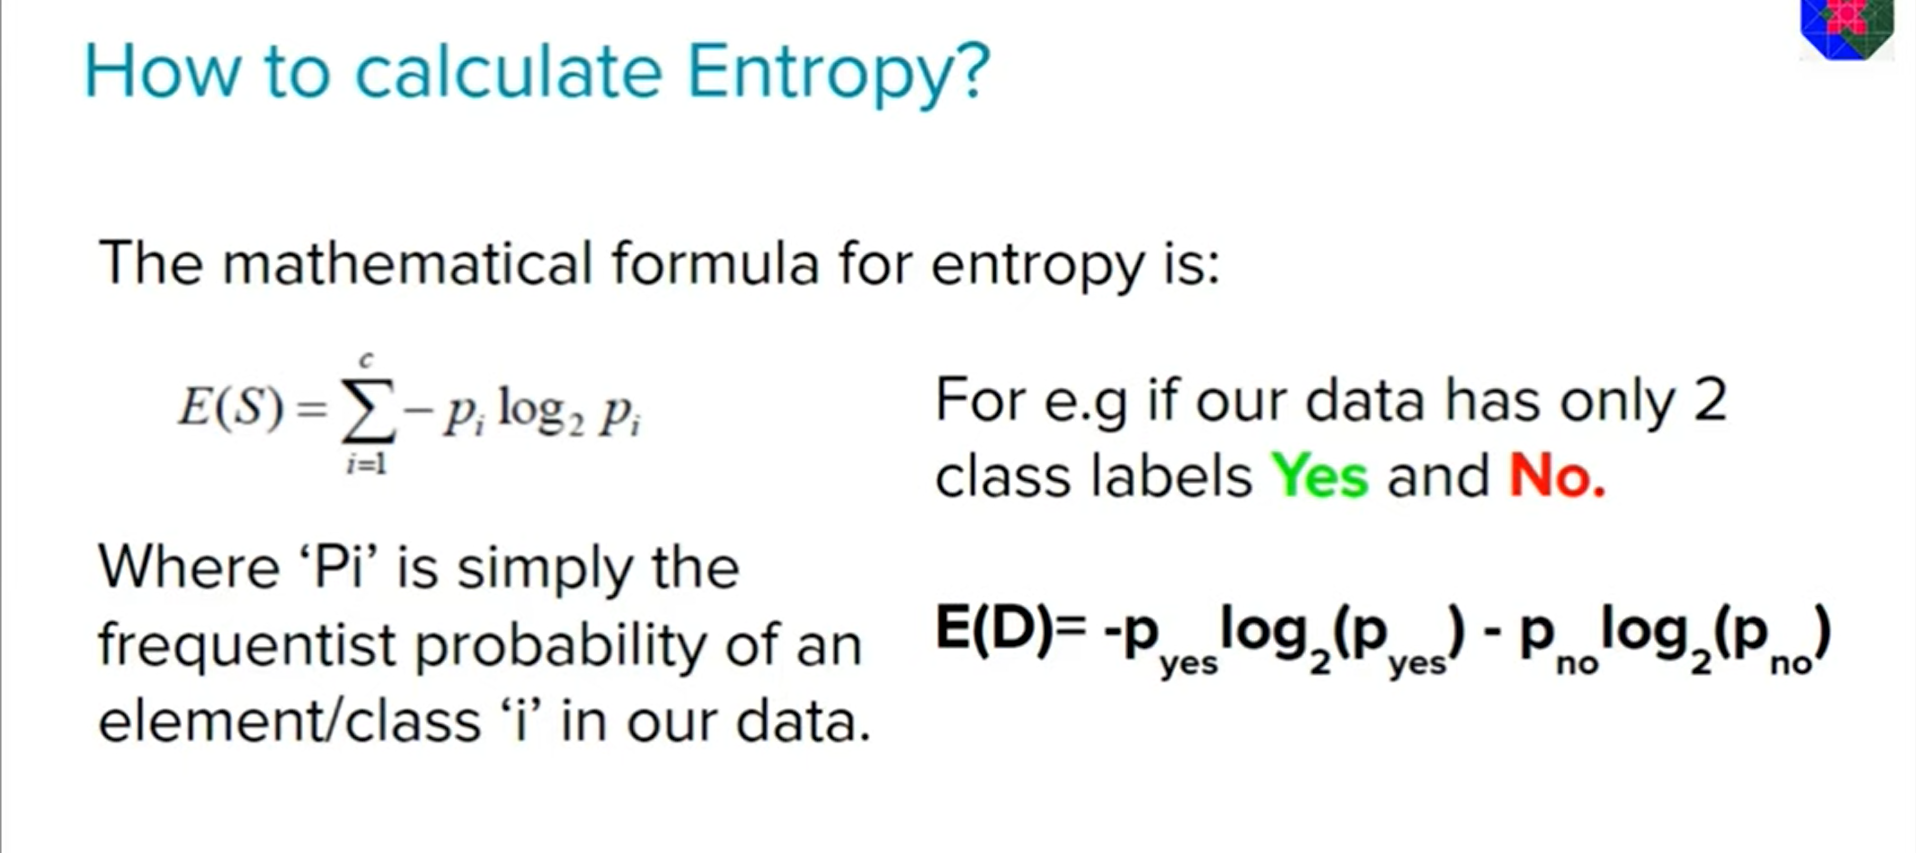
## Information Gain
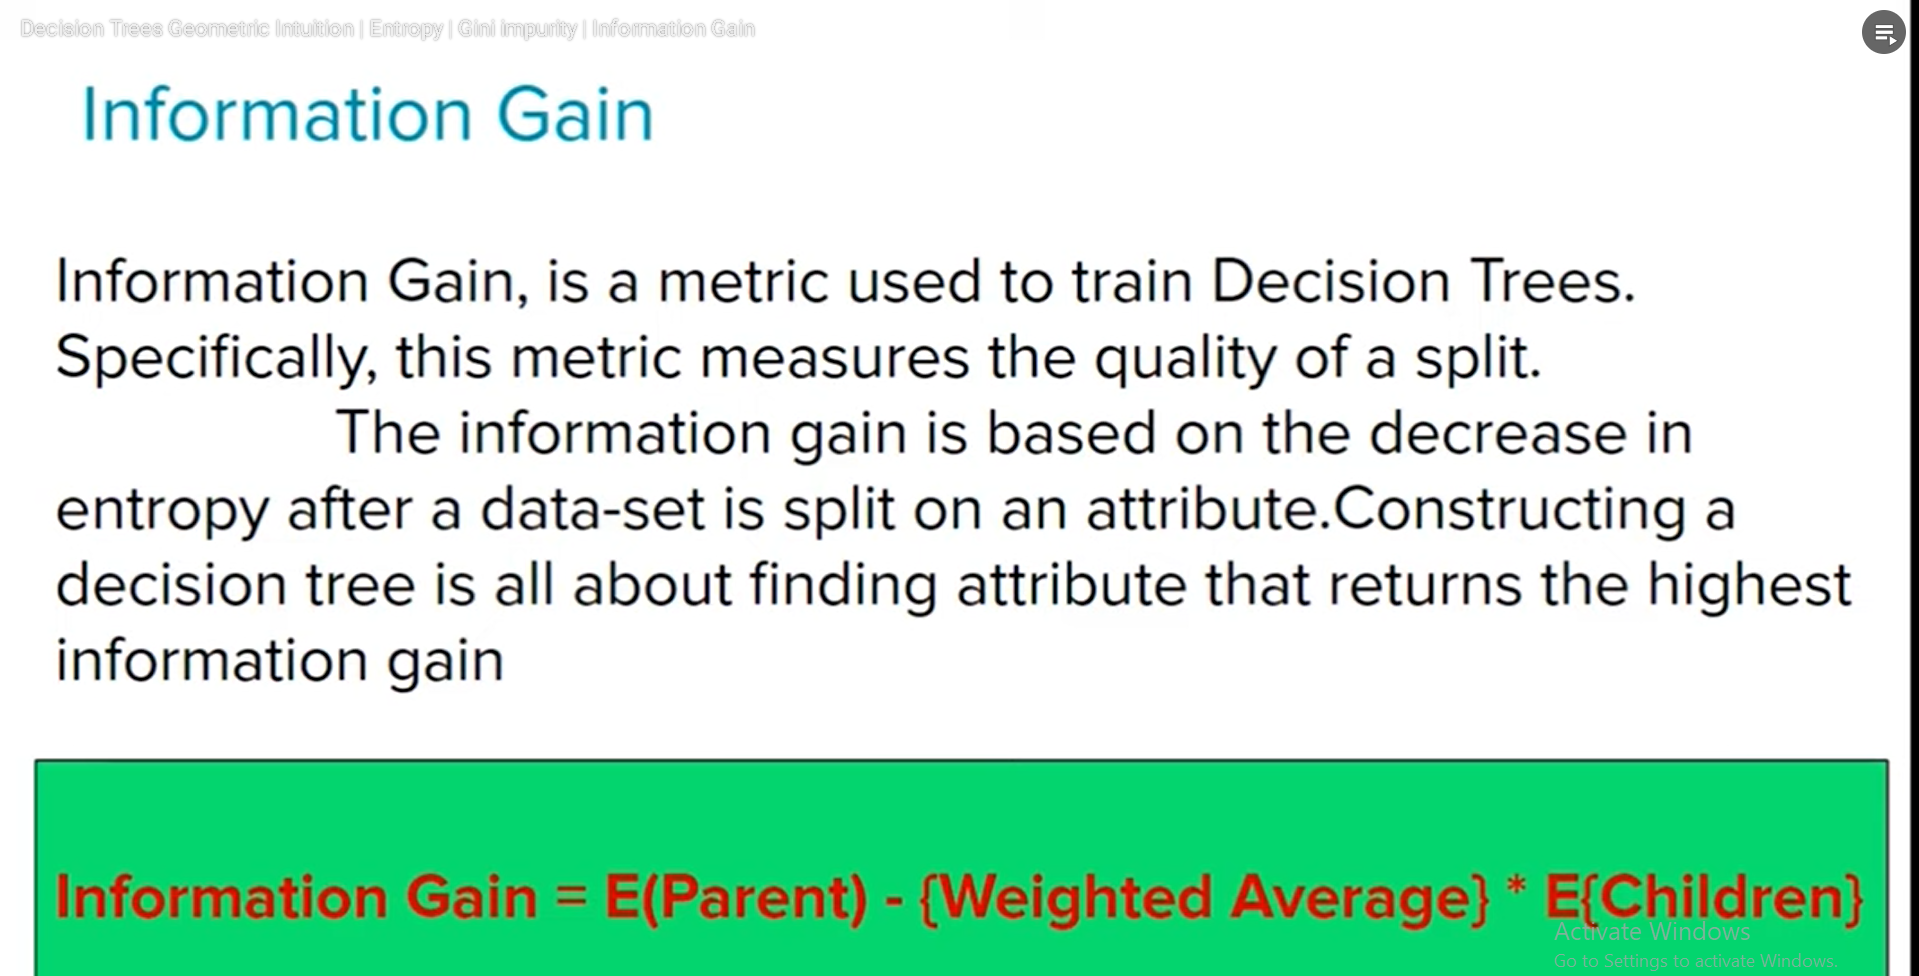
## Gini
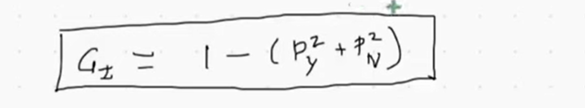

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [106]:
df=pd.read_csv("winequality-red.csv")
bins = [2, 5, 7, 9]  # 2-5 = low, 6-7 = medium, 8-9 = high
labels = ["low", "medium", "high"]
df["quality"] = pd.cut(df["quality"], bins=bins, labels=labels)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,low
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,medium
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,medium
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,low


In [107]:
X=df.drop(columns=["quality"])
y=df["quality"]

In [108]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [109]:
from sklearn.model_selection import GridSearchCV
modell = DecisionTreeClassifier(random_state=42)
params = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV( estimator=modell,param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1,verbose=1)
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)
print(best_dt)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV score: 0.7208762254901961
DecisionTreeClassifier(max_depth=8, min_samples_leaf=2, min_samples_split=10,
                       random_state=42)


In [110]:
model=best_dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=5,random_state=42)

In [111]:
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [112]:
yy_pred=model.predict(X_test)
print("Accuracy_score: \n",accuracy_score(y_test, yy_pred))
print("Classification_report: \n",classification_report(y_test, yy_pred))
print("Confusion_matrix: \n",confusion_matrix(y_test, yy_pred))

Accuracy_score: 
 0.740625
Classification_report: 
               precision    recall  f1-score   support

        high       0.00      0.00      0.00         4
         low       0.72      0.75      0.73       146
      medium       0.76      0.75      0.76       170

    accuracy                           0.74       320
   macro avg       0.49      0.50      0.50       320
weighted avg       0.73      0.74      0.74       320

Confusion_matrix: 
 [[  0   0   4]
 [  0 109  37]
 [  0  42 128]]


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [113]:
y_pred=model.predict(X_train)
print("Accuracy_score: \n",accuracy_score(y_train, y_pred))
print("Classification_report: \n",classification_report(y_train, y_pred))
print("Confusion_matrix: \n",confusion_matrix(y_train, y_pred))

Accuracy_score: 
 0.8053166536356529
Classification_report: 
               precision    recall  f1-score   support

        high       0.00      0.00      0.00        14
         low       0.79      0.82      0.81       598
      medium       0.82      0.81      0.81       667

    accuracy                           0.81      1279
   macro avg       0.54      0.54      0.54      1279
weighted avg       0.80      0.81      0.80      1279

Confusion_matrix: 
 [[  0   1  13]
 [  0 492 106]
 [  0 129 538]]


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [115]:
model.predict([[11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8]])

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['medium'], dtype=object)

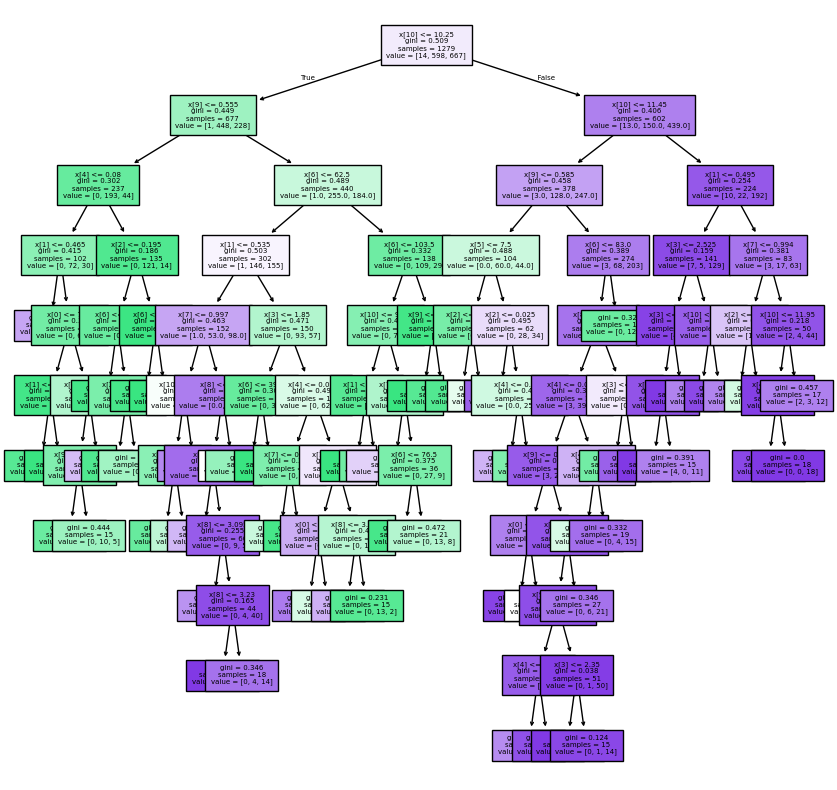

In [114]:
plt.figure(figsize=(10, 10))
plot_tree(model,filled=True,fontsize=5)
plt.show()